# EDA — Flight Delay Prediction

Run the load cells first. Then each person does their section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_parquet('combined_preprocessed.parquet')
print(df.shape)
df.head()

(6304794, 136)


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,DEP_DELAY,DEP_DEL15,DISTANCE,WEATHER_DELAY,NAS_DELAY,...,DEST_STATE_TT,DEST_STATE_TX,DEST_STATE_UT,DEST_STATE_VA,DEST_STATE_VI,DEST_STATE_VT,DEST_STATE_WA,DEST_STATE_WI,DEST_STATE_WV,DEST_STATE_WY
0,2025,1,1,1,3,-3,0.0,2475.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,2025,1,1,1,3,-7,0.0,2475.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,2025,1,1,1,3,36,1.0,708.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,2025,1,1,1,3,1,0.0,2176.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,2025,1,1,1,3,-1,0.0,1440.0,0.0,44.0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6304794 entries, 0 to 6304793
Columns: 136 entries, YEAR to DEST_STATE_WY
dtypes: float32(9), int16(2), int64(119), int8(4), object(2)
memory usage: 5.9+ GB


In [3]:
df.describe()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,DEP_DELAY,DEP_DEL15,DISTANCE,WEATHER_DELAY,NAS_DELAY,...,DEST_STATE_TT,DEST_STATE_TX,DEST_STATE_UT,DEST_STATE_VA,DEST_STATE_VI,DEST_STATE_VT,DEST_STATE_WA,DEST_STATE_WI,DEST_STATE_WV,DEST_STATE_WY
count,6304794.0,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,1.418604e+06,1.418604e+06,...,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06
mean,2025.0,2.668552e+00,6.912653e+00,1.571577e+01,3.990125e+00,1.373034e+01,2.197349e-01,8.455319e+02,4.664107e+00,1.596707e+01,...,1.800217e-04,1.072674e-01,1.786212e-02,5.890914e-03,9.061359e-04,9.245346e-04,2.800203e-02,7.921432e-03,6.108050e-04,2.003713e-03
std,0.0,1.046404e+00,3.354246e+00,8.765782e+00,2.003025e+00,5.775787e+01,4.210650e-01,6.005450e+02,3.463229e+01,3.644205e+01,...,1.341601e-02,3.094530e-01,1.324503e-01,7.652589e-02,3.008845e-02,3.039210e-02,1.649785e-01,8.864922e-02,2.470692e-02,4.471799e-02
min,2025.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.150000e+02,0.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025.0,2.000000e+00,4.000000e+00,8.000000e+00,2.000000e+00,-6.000000e+00,0.000000e+00,4.030000e+02,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2025.0,3.000000e+00,7.000000e+00,1.600000e+01,4.000000e+00,-2.000000e+00,0.000000e+00,6.920000e+02,0.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2025.0,4.000000e+00,1.000000e+01,2.300000e+01,6.000000e+00,1.100000e+01,0.000000e+00,1.081000e+03,0.000000e+00,1.900000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2025.0,4.000000e+00,1.200000e+01,3.100000e+01,7.000000e+00,4.352000e+03,1.000000e+00,5.095000e+03,2.394000e+03,1.706000e+03,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


---
# Aryan — Target distribution & class imbalance

Goal: understand the target (`DELAY_CLASS`) and how balanced/imbalanced it is.

Plots to make:
1. Bar chart of class counts (how many flights in each delay bin)
2. Pie chart of class percentages
3. Histogram of raw `ARR_DELAY` (to see where the bins fall)
4. Boxplot of `ARR_DELAY` (to see outliers)

Notes: flag the class imbalance, mention if any class is so rare we might want to merge it.

In [ ]:
# TODO (Aryan): class count bar chart + percentages


In [ ]:
# TODO (Aryan): histogram + boxplot of ARR_DELAY


---
# Sam — Carrier analysis

Goal: which airlines delay the most? Do different carriers get delayed for different reasons?

Plots to make:
1. Delay rate by carrier (% of flights in each carrier that are delayed 15+ min)
2. Average `ARR_DELAY` by carrier (bar chart, sorted)
3. Stacked bar: for each carrier, % of delay minutes caused by carrier / weather / NAS / security / late aircraft
4. Count of flights per carrier (to see which are dominant)

Notes: which carrier is most reliable? Which one is worst? Any surprises?

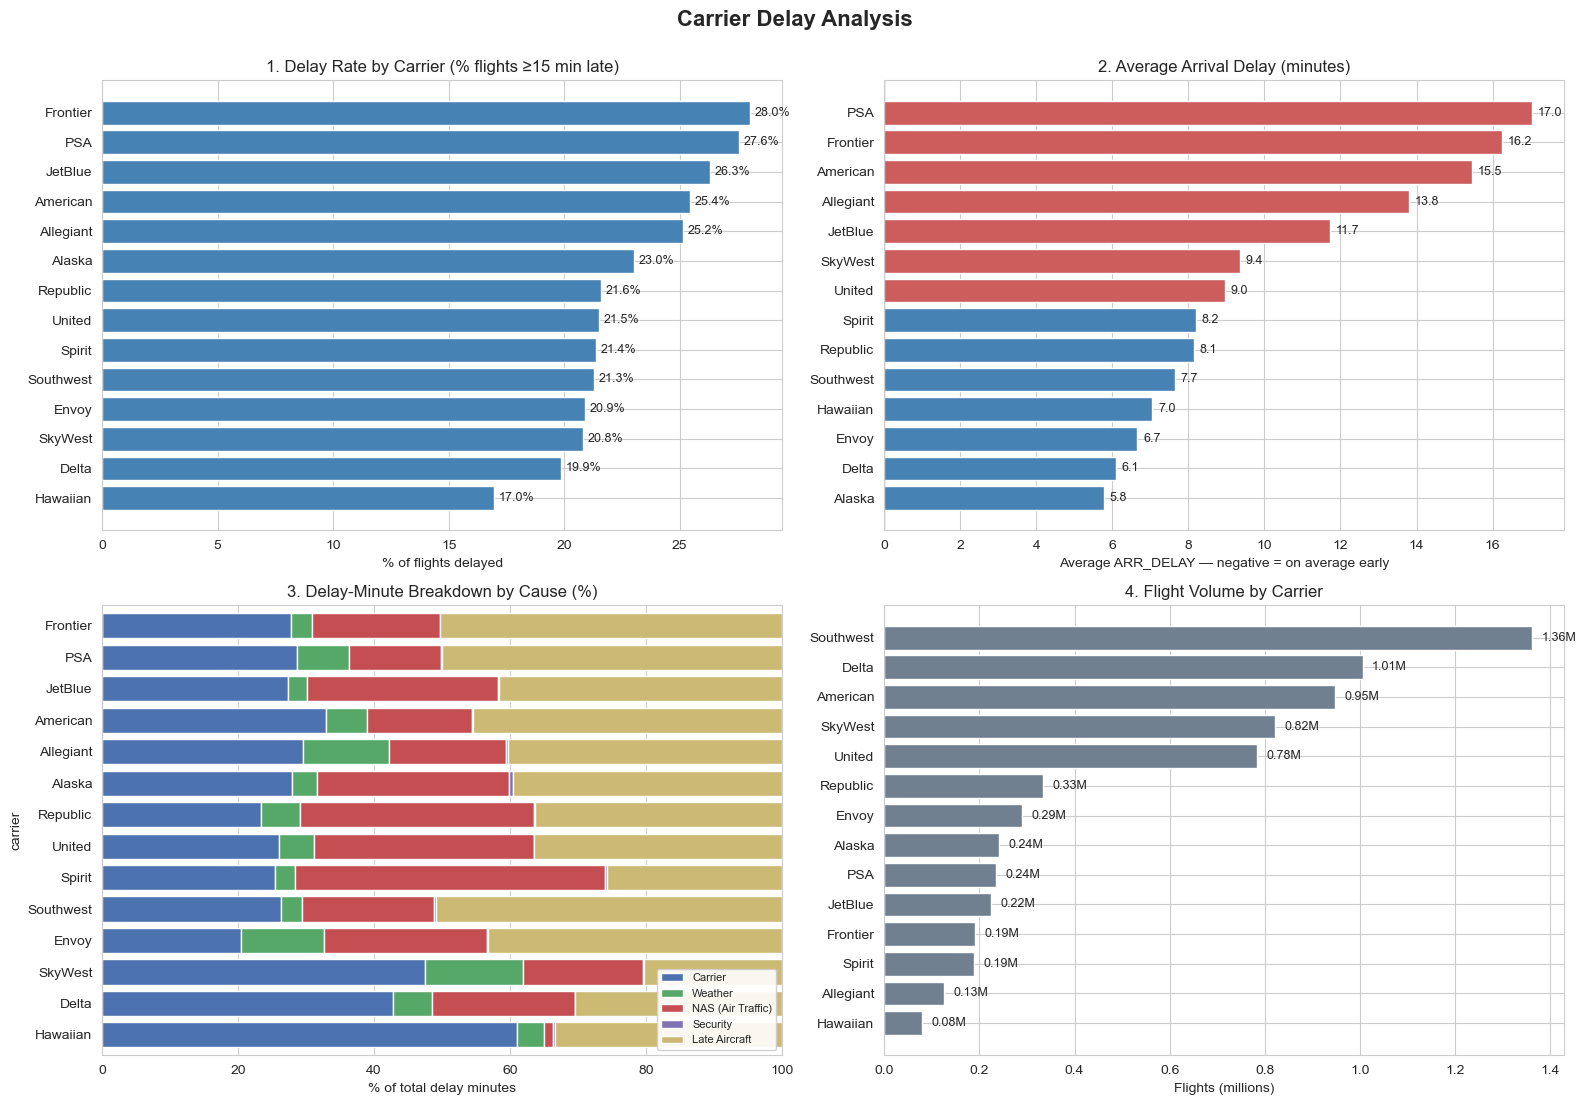

In [11]:
# TODO (Sam): delay rate by carrier
"""
Airline delay analysis.

Questions:
  - Which airlines delay the most?
  - Do different carriers get delayed for different reasons?
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# 1. Load ONLY the columns we need.
#    The full file is 6.9M rows x 31 cols and will OOM a 4GB container;
#    these 9 columns fit fine.
# ---------------------------------------------------------------
cols = [
    'OP_UNIQUE_CARRIER',
    'ARR_DEL15',
    'ARR_DELAY',
    'CANCELLED',
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY',
]
df = pd.read_parquet("combined.parquet")

# Cancelled flights have no arrival -> drop for delay analysis
df = df[df['CANCELLED'] != 1].copy()

# IATA code -> readable name (makes plots interpretable)
carrier_names = {
    'AA': 'American',  'AS': 'Alaska',   'B6': 'JetBlue',  'DL': 'Delta',
    'F9': 'Frontier',  'G4': 'Allegiant','HA': 'Hawaiian', 'MQ': 'Envoy',
    'NK': 'Spirit',    'OH': 'PSA',      'OO': 'SkyWest',  'UA': 'United',
    'WN': 'Southwest', 'YX': 'Republic', '9E': 'Endeavor', 'YV': 'Mesa',
    'EV': 'ExpressJet','VX': 'Virgin America',
}
df['carrier'] = df['OP_UNIQUE_CARRIER'].map(carrier_names).fillna(df['OP_UNIQUE_CARRIER'])

# ---------------------------------------------------------------
# 2. Aggregate everything in one groupby
# ---------------------------------------------------------------
agg = df.groupby('carrier').agg(
    n_flights           =('ARR_DEL15',           'size'),
    delay_rate          =('ARR_DEL15',           'mean'),   # fraction >=15 min late
    avg_arr_delay       =('ARR_DELAY',           'mean'),
    carrier_delay       =('CARRIER_DELAY',       'sum'),
    weather_delay       =('WEATHER_DELAY',       'sum'),
    nas_delay           =('NAS_DELAY',           'sum'),
    security_delay      =('SECURITY_DELAY',      'sum'),
    late_aircraft_delay =('LATE_AIRCRAFT_DELAY', 'sum'),
)
agg['delay_rate_pct'] = agg['delay_rate'] * 100

# % breakdown of delay minutes by cause
reason_cols = ['carrier_delay', 'weather_delay', 'nas_delay',
               'security_delay', 'late_aircraft_delay']
totals = agg[reason_cols].sum(axis=1).replace(0, np.nan)
reason_pct = agg[reason_cols].div(totals, axis=0) * 100

# ---------------------------------------------------------------
# 3. Plots
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Carrier Delay Analysis', fontsize=16, fontweight='bold', y=1.00)

# Plot 1 — delay rate (% of flights 15+ min late), sorted
ax = axes[0, 0]
d = agg['delay_rate_pct'].sort_values()
bars = ax.barh(d.index, d.values, color='steelblue')
ax.set_title('1. Delay Rate by Carrier (% flights ≥15 min late)')
ax.set_xlabel('% of flights delayed')
for bar, v in zip(bars, d.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)

# Plot 2 — average arrival delay (minutes)
ax = axes[0, 1]
d = agg['avg_arr_delay'].sort_values()
med = d.median()
colors = ['#2a9d3f' if v < 0 else 'steelblue' if v < med else 'indianred'
          for v in d.values]
bars = ax.barh(d.index, d.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('2. Average Arrival Delay (minutes)')
ax.set_xlabel('Average ARR_DELAY — negative = on average early')
for bar, v in zip(bars, d.values):
    ax.text(v + (0.15 if v >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)

# Plot 3 — stacked % of delay minutes by cause, per carrier
ax = axes[1, 0]
order = agg['delay_rate_pct'].sort_values(ascending=False).index  # worst on top
plot_df = reason_pct.loc[order].copy()
plot_df.columns = ['Carrier', 'Weather', 'NAS (Air Traffic)',
                   'Security', 'Late Aircraft']
plot_df.plot(kind='barh', stacked=True, ax=ax,
             color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'],
             width=0.8)
ax.set_title('3. Delay-Minute Breakdown by Cause (%)')
ax.set_xlabel('% of total delay minutes')
ax.set_xlim(0, 100)
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.invert_yaxis()

# Plot 4 — flight volume per carrier
ax = axes[1, 1]
d = (agg['n_flights'] / 1e6).sort_values()
bars = ax.barh(d.index, d.values, color='slategray')
ax.set_title('4. Flight Volume by Carrier')
ax.set_xlabel('Flights (millions)')
for bar, v in zip(bars, d.values):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()



In [10]:
# TODO (Sam): delay reason breakdown per carrier
print("\n=== Summary (sorted by delay rate, best -> worst) ===")
summary = (agg[['n_flights', 'delay_rate_pct', 'avg_arr_delay']]
           .sort_values('delay_rate_pct'))
summary['n_flights'] = summary['n_flights'].map(lambda x: f'{x:>10,}')
print(summary.to_string(float_format='%.2f'))

print("\n=== Delay-cause mix, % of delay minutes (worst carrier first) ===")
print(reason_pct.loc[order].round(1).to_string())

best  = agg['delay_rate_pct'].idxmin()
worst = agg['delay_rate_pct'].idxmax()
print(f"\nMost reliable: {best}  ({agg.loc[best,  'delay_rate_pct']:.1f}% delayed, "
      f"avg {agg.loc[best,  'avg_arr_delay']:.1f} min)")
print(f"Worst:         {worst} ({agg.loc[worst, 'delay_rate_pct']:.1f}% delayed, "
      f"avg {agg.loc[worst, 'avg_arr_delay']:.1f} min)")


=== Summary (sorted by delay rate, best -> worst) ===
            n_flights  delay_rate_pct  avg_arr_delay
carrier                                             
Hawaiian       79,294           16.98           7.05
Delta       1,005,316           19.87           6.09
SkyWest       822,229           20.81           9.36
Envoy         290,099           20.91           6.66
Southwest   1,360,967           21.27           7.65
Spirit        188,947           21.37           8.19
United        782,780           21.52           8.97
Republic      332,966           21.58           8.14
Alaska        241,732           23.02           5.79
Allegiant     126,234           25.15          13.80
American      946,979           25.44          15.45
JetBlue       224,044           26.33          11.72
PSA           235,426           27.55          17.03
Frontier      191,216           28.02          16.25

=== Delay-cause mix, % of delay minutes (worst carrier first) ===
           carrier_delay  weat

---
# Dennis — Time patterns

Goal: when do delays happen? Morning vs evening, weekday vs weekend, winter vs summer.

Plots to make:
1. Delay rate by `DEP_HOUR` (line chart, 0–23)
2. Delay rate by `DAY_OF_WEEK` (bar chart, Mon–Sun)
3. Delay rate by `MONTH` (line chart, 1–12)
4. Heatmap: `DAY_OF_WEEK` × `DEP_HOUR` showing delay rate

Notes: confirm or deny the "evening flights delay more" claim. Any seasonal patterns?

In [ ]:
# TODO (Dennis): delay rate by DEP_HOUR


In [ ]:
# TODO (Dennis): delay rate by DAY_OF_WEEK and MONTH


In [ ]:
# TODO (Dennis): heatmap DAY_OF_WEEK x DEP_HOUR


---
# Wahid — Geography, distance & delay causes

Goal: where do delays happen, and what causes them overall?

Plots to make:
1. Top 10 origin states by delay rate (bar chart)
2. Top 10 destination states by delay rate (bar chart)
3. Scatter: `DISTANCE` vs `ARR_DELAY` (sample 10k rows so it's not a blob)
4. Pie chart: overall breakdown of delay causes (sum of `WEATHER_DELAY`, `CARRIER_DELAY`, `NAS_DELAY`, `SECURITY_DELAY`, `LATE_AIRCRAFT_DELAY`)

Notes: are big hub states (IL, GA, TX, CA) worse than others? Does distance actually matter?

In [ ]:
# TODO (Wahid): top 10 states by delay rate (origin and dest)


In [ ]:
# TODO (Wahid): distance vs delay scatter


In [ ]:
# TODO (Wahid): delay cause breakdown (pie chart)


---
# Shared — Correlation matrix

One team member runs this. Shows multicollinearity before modeling.

In [ ]:
# TODO: correlation heatmap of numeric columns
# Suggestion: df.select_dtypes(include=np.number).corr() -> sns.heatmap
